Пожалуйста, загрузите файл bank-additional-full.csv


Saving bank-additional-full.csv to bank-additional-full.csv
Размер датасета: (41188, 21)
Числовые признаки: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

=== Задание 1 ===
Число объектов: 41188
Число числовых признаков: 10


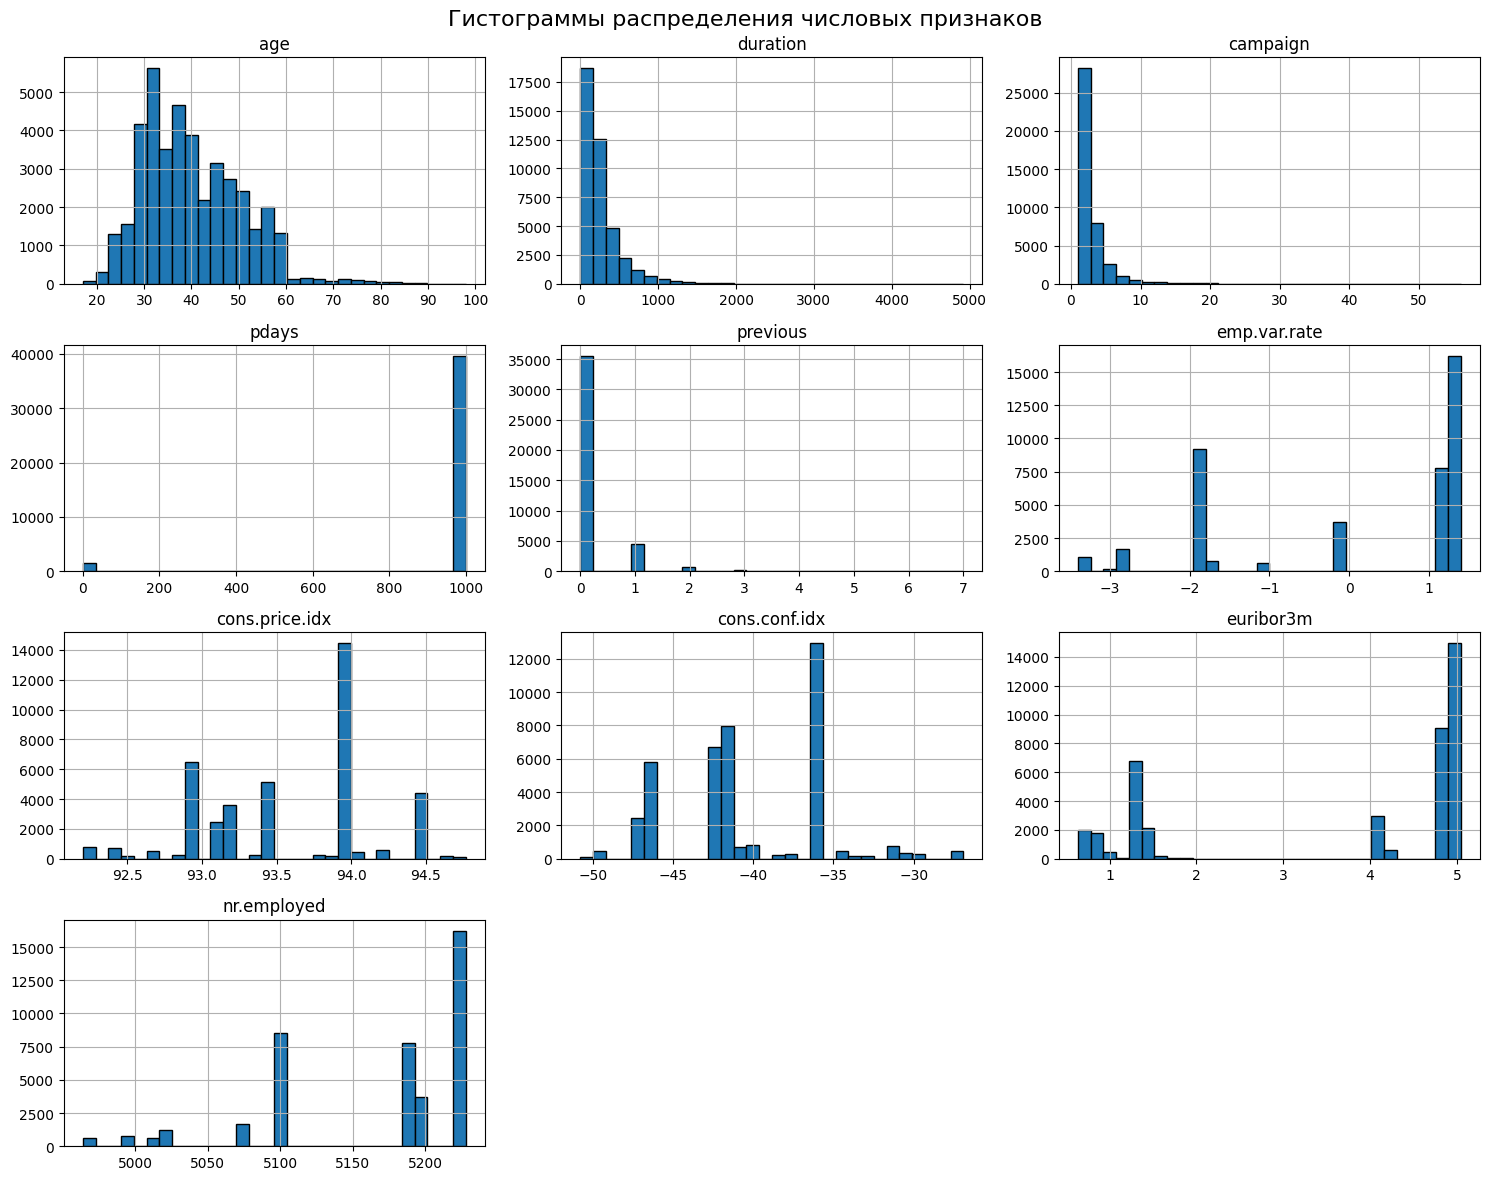

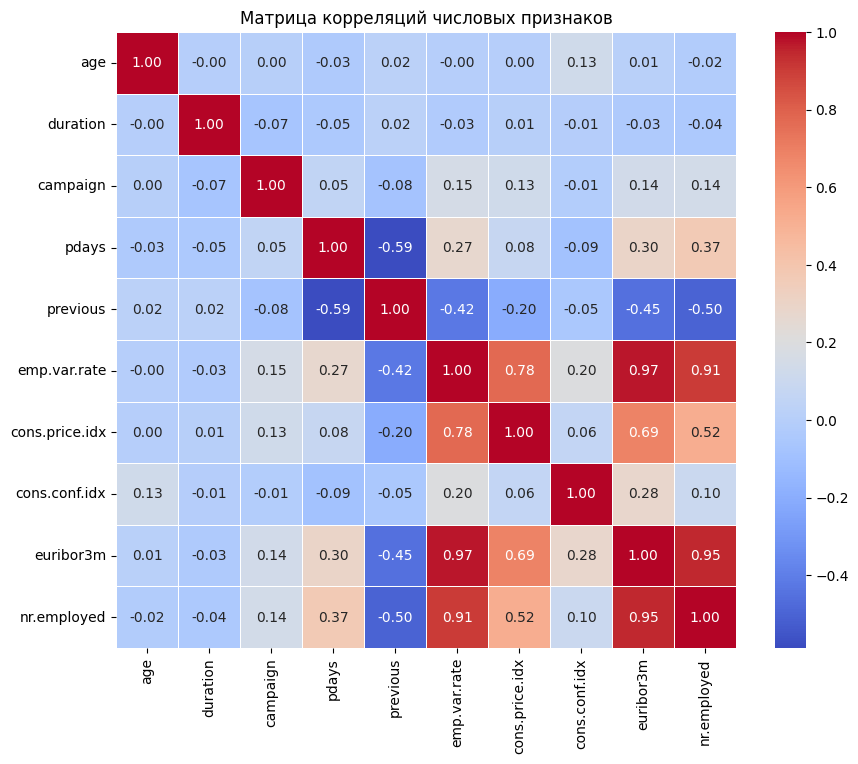

Сильно коррелированные признаки (|r| > 0.8):
  emp.var.rate — euribor3m: 0.972
  emp.var.rate — nr.employed: 0.907
  euribor3m — nr.employed: 0.945
Часть признаков могут быть избыточны, например, euribor3m и nr.employed часто коррелируют с emp.var.rate и cons.conf.idx.

=== Задание 2 ===
Первые 5 объяснённых дисперсий (my PCA): [0.38954957 0.13588832 0.10776451 0.10503605 0.09294534]
Первые 5 объяснённых дисперсий (sklearn PCA): [0.38954957 0.13588832 0.10776451 0.10503605 0.09294534]
Совпадение проекций? Макс. разница: 28.600890135901572


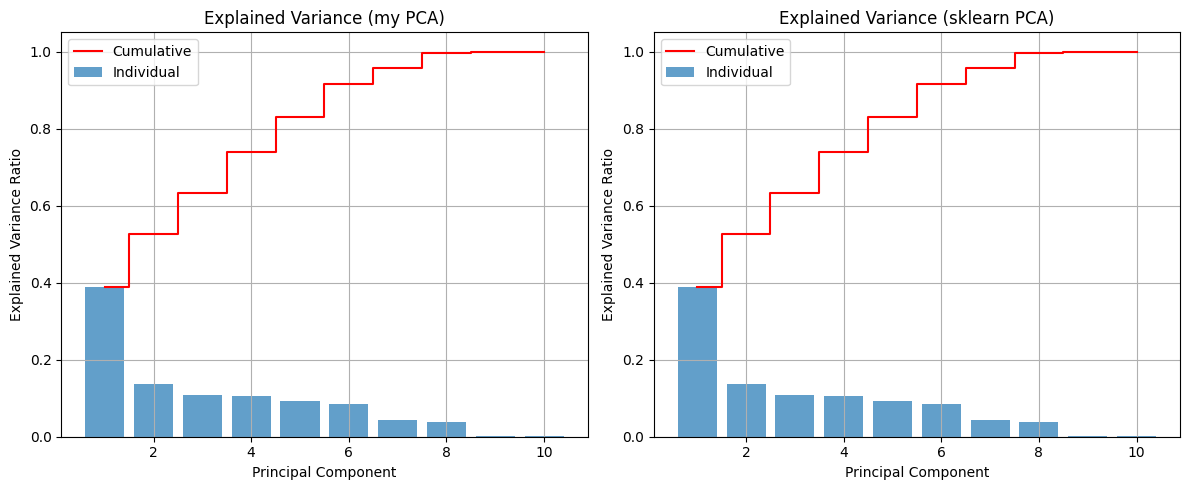

Для объяснения 80% дисперсии требуется 5 компонент.
Для объяснения 95% дисперсии требуется 7 компонент.

=== Задание 3 ===
Коэффициенты признаков в первых трёх главных компонентах:
                   PC1    PC2    PC3
age            -0.003  0.294  0.659
duration       -0.050  0.095  0.042
campaign        0.198 -0.009 -0.336
pdays           0.449 -0.733  0.262
previous       -0.604  0.553 -0.292
emp.var.rate    0.963  0.190 -0.094
cons.price.idx  0.723  0.325 -0.287
cons.conf.idx   0.200  0.499  0.530
euribor3m       0.968  0.173 -0.003
nr.employed     0.928 -0.016 -0.031

PC1: наибольший вклад
  euribor3m: 0.968
  emp.var.rate: 0.963
  nr.employed: 0.928

PC2: наибольший вклад
  pdays: 0.733
  previous: 0.553
  cons.conf.idx: 0.499

PC3: наибольший вклад
  age: 0.659
  cons.conf.idx: 0.530
  campaign: 0.336

1. На первую компоненту больше всего влияют признаки: ['euribor3m', 'emp.var.rate', 'nr.employed']
2. Первую компоненту можно интерпретировать как комбинацию исходных признаков, св

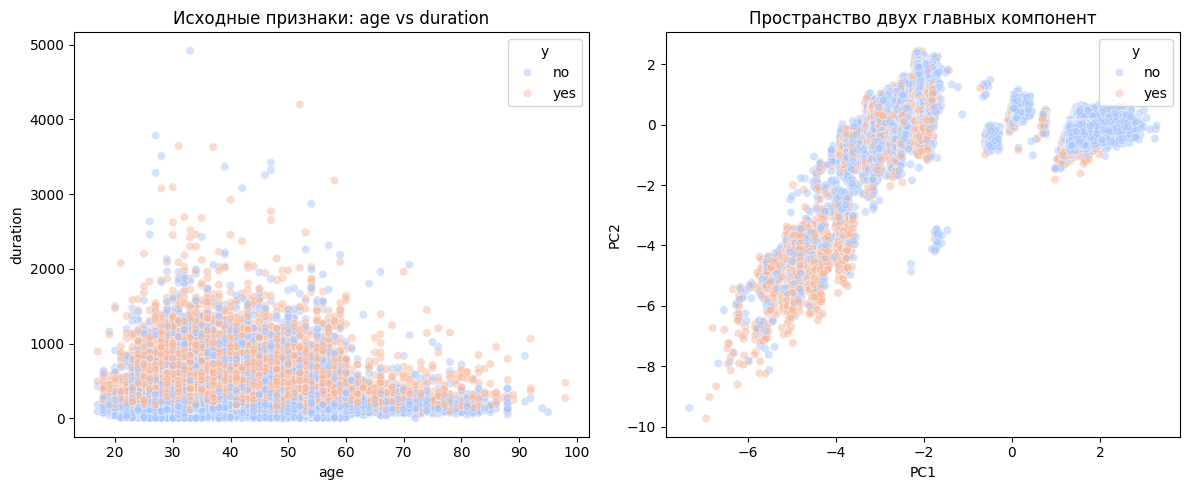

Визуализация после PCA улучшилась: классы (y) стали более разделимы, структура данных более компактна и выявляет кластеры.
В пространстве главных компонент структура заметнее, потому что PCA выделяет направления максимальной дисперсии, подавляя шум и корреляции.

=== Задание 5 ===
Выполняется t-SNE с perplexity=5 ...
Выполняется t-SNE с perplexity=30 ...
Выполняется t-SNE с perplexity=50 ...
Выполняется UMAP с n_neighbors=5, min_dist=0.1 ...
Выполняется UMAP с n_neighbors=30, min_dist=0.1 ...
Выполняется UMAP с n_neighbors=30, min_dist=0.5 ...


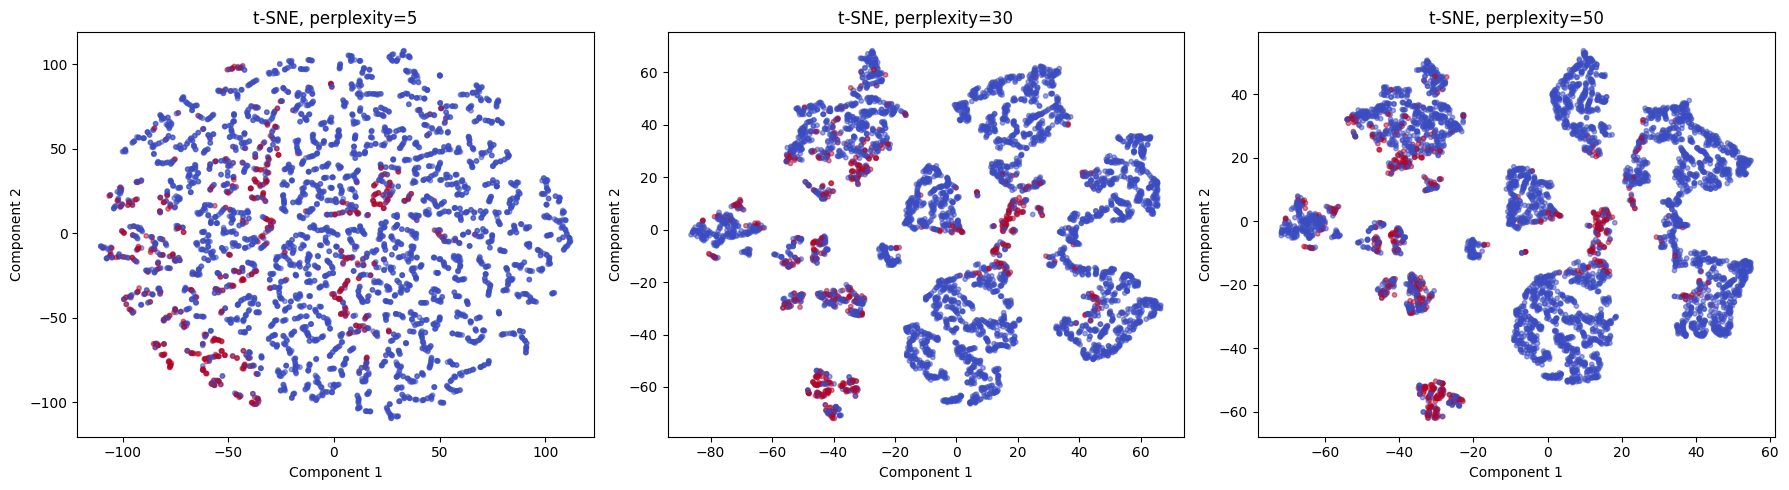

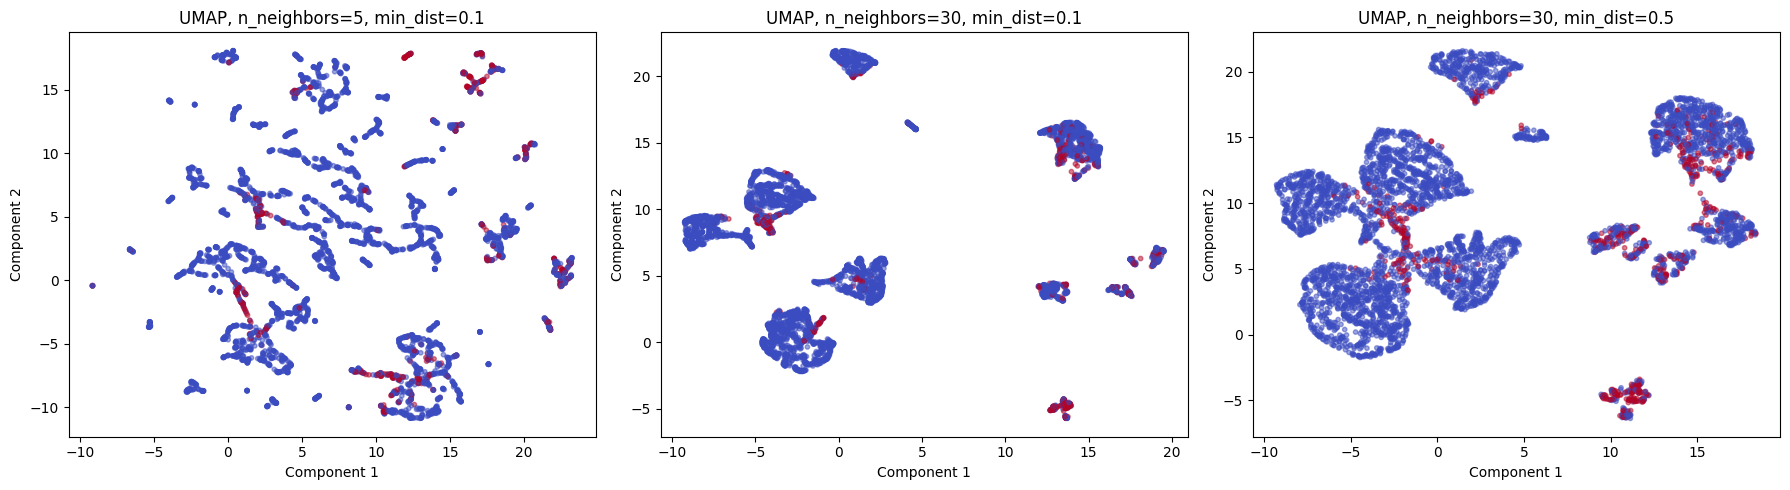

Ответы на вопросы:
1. При малом perplexity (5) t-SNE образует множество мелких кластеров, при увеличении (30,50) кластеры становятся более обобщёнными.
2. UMAP при малых n_neighbors образует более разреженные кластеры, при увеличении – более плотные; min_dist влияет на компактность кластеров.
3. Наиболее интерпретируемую визуализацию даёт UMAP (хорошо разделяет классы) или t-SNE с подобранным perplexity. Результаты отличаются из-за разных математических подходов: t-SNE сохраняет локальную структуру, UMAP – и локальную, и глобальную.

=== Задание 6 ===
Рассматриваемые значения k: [2, 5, 10]
k =  2 : MSE = 0.474562
k =  5 : MSE = 0.168816
k = 10 : MSE = 0.000000

Таблица ошибок восстановления:
 Число компонент  Ошибка восстановления (MSE)
               2                 4.745621e-01
               5                 1.688162e-01
              10                 5.166602e-31


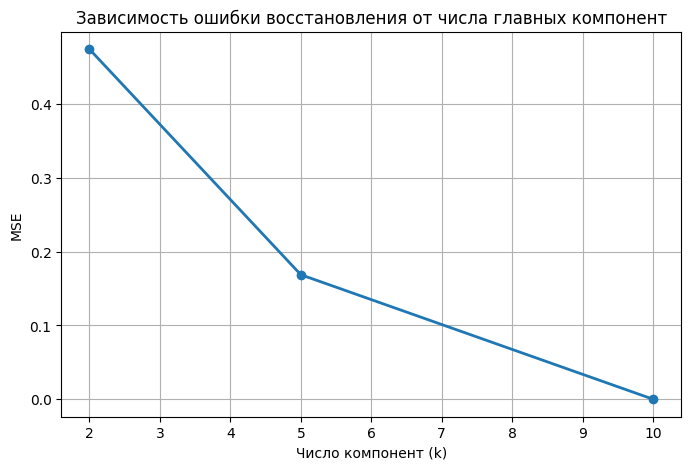


Интерпретация:
1. При малом k ошибка большая, потому что теряется много информации (отбрасываются компоненты с малой дисперсией).
2. Увеличение k уменьшает ошибку, так как сохраняется больше вариации данных.
3. При использовании всех компонент (k = полная размерность) можно полностью восстановить исходные данные (MSE ≈ 0).
4. Накопленная объяснённая дисперсия напрямую связана с MSE: чем выше доля сохранённой дисперсии, тем меньше ошибка восстановления.
5. Разумное число компонент можно определить по графику MSE (точка излома/«колено») или по критерию 80-95% объяснённой дисперсии.

=== Задание 7. Итоговый анализ ===
1. Снижение размерности помогает визуализировать многомерные данные, ускоряет обучение моделей, уменьшает переобучение и шум.
2. Не всегда полезно: при сильной нелинейной структуре линейные методы (PCA) могут разрушить полезные взаимосвязи; также теряется интерпретируемость.
3. Линейные методы (PCA) работают хуже нелинейных, когда данные имеют сложную нелинейную структуру (

In [ ]:
# -*- coding: utf-8 -*-
"""
# Лабораторная работа №3: Снижение размерности (PCA, t-SNE, UMAP)
## Датасет: Bank Marketing (bank-additional-full.csv)
"""

# Загрузка необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error
import umap
import warnings
warnings.filterwarnings('ignore')

# Для отображения графиков в Colab
%matplotlib inline

from google.colab import files
print("Пожалуйста, загрузите файл bank-additional-full.csv")
uploaded = files.upload()

# Получим имя загруженного файла
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, sep=';')


print("Размер датасета:", df.shape)
df.head()

# Определим числовые признаки (на основе описания данных)
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed']
# Целевая переменная (для окраски)
target = 'y'

# Проверим, что все колонки существуют
missing = [c for c in numeric_cols if c not in df.columns]
if missing:
    print("Внимание! Отсутствуют колонки:", missing)
else:
    print("Числовые признаки:", numeric_cols)

# Задание 1. Геометрия данных в пространстве признаков
print("\n=== Задание 1 ===")
print(f"Число объектов: {df.shape[0]}")
print(f"Число числовых признаков: {len(numeric_cols)}")

# Гистограммы распределения признаков
df_numeric = df[numeric_cols]
df_numeric.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Гистограммы распределения числовых признаков", size=16)
plt.tight_layout()
plt.show()

# Матрица корреляций
plt.figure(figsize=(10, 8))
corr = df_numeric.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Матрица корреляций числовых признаков")
plt.show()

# Анализ сильных корреляций
high_corr = (corr.abs() > 0.8) & (corr.abs() < 1.0)
high_corr_pairs = [(i, j, corr.loc[i, j]) for i in high_corr.columns for j in high_corr.index if high_corr.loc[i, j] and i < j]
if high_corr_pairs:
    print("Сильно коррелированные признаки (|r| > 0.8):")
    for i, j, r in high_corr_pairs:
        print(f"  {i} — {j}: {r:.3f}")
else:
    print("Нет сильно коррелированных признаков (|r| > 0.8).")

# Можно ли предположить, что часть признаков избыточна?
print("Часть признаков могут быть избыточны, например, euribor3m и nr.employed часто коррелируют с emp.var.rate и cons.conf.idx.")

# Задание 2. Реализация PCA с нуля
print("\n=== Задание 2 ===")
# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# 1. Реализация PCA через NumPy
def my_pca(X, n_components=None):
    # Центрирование (уже сделано StandardScaler, но для надёжности)
    X_centered = X - np.mean(X, axis=0)
    # Ковариационная матрица
    cov_matrix = np.cov(X_centered, rowvar=False)
    # Собственные значения и векторы
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    # Сортировка по убыванию собственных значений
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    if n_components is not None:
        eigenvectors = eigenvectors[:, :n_components]
    # Проекция данных
    X_pca = X_centered @ eigenvectors
    return X_pca, eigenvalues, eigenvectors

# Применим ко всем компонентам (полная размерность)
X_pca_my, eigvals_my, eigvecs_my = my_pca(X_scaled, n_components=None)
explained_variance_ratio_my = eigvals_my / np.sum(eigvals_my)
cumsum_my = np.cumsum(explained_variance_ratio_my)

# 2. Sklearn PCA
pca_sk = SklearnPCA()
X_pca_sk = pca_sk.fit_transform(X_scaled)
explained_variance_ratio_sk = pca_sk.explained_variance_ratio_
cumsum_sk = np.cumsum(explained_variance_ratio_sk)

# Сравнение результатов (первые 5 компонент)
print("Первые 5 объяснённых дисперсий (my PCA):", explained_variance_ratio_my[:5])
print("Первые 5 объяснённых дисперсий (sklearn PCA):", explained_variance_ratio_sk[:5])
print("Совпадение проекций? Макс. разница:", np.max(np.abs(X_pca_my[:, :5] - X_pca_sk[:, :5])))

# График объяснённой дисперсии и накопленной дисперсии
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio_my)+1), explained_variance_ratio_my, alpha=0.7, label='Individual')
plt.step(range(1, len(cumsum_my)+1), cumsum_my, where='mid', color='red', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance (my PCA)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(1, len(explained_variance_ratio_sk)+1), explained_variance_ratio_sk, alpha=0.7, label='Individual')
plt.step(range(1, len(cumsum_sk)+1), cumsum_sk, where='mid', color='red', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance (sklearn PCA)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Сколько компонент объясняют 80% и 95% дисперсии?
n_80 = np.argmax(cumsum_sk >= 0.8) + 1
n_95 = np.argmax(cumsum_sk >= 0.95) + 1
print(f"Для объяснения 80% дисперсии требуется {n_80} компонент.")
print(f"Для объяснения 95% дисперсии требуется {n_95} компонент.")

# Задание 3. Интерпретация главных компонент
print("\n=== Задание 3 ===")
# loadings = eigenvectors * sqrt(eigenvalues) = компоненты в терминах исходных признаков
loadings = eigvecs_my * np.sqrt(eigvals_my)
# Для первых трёх компонент
n_comp = 3
loadings_df = pd.DataFrame(loadings[:, :n_comp], index=numeric_cols, columns=[f'PC{i+1}' for i in range(n_comp)])
print("Коэффициенты признаков в первых трёх главных компонентах:\n", loadings_df.round(3))

# Признаки с наибольшим вкладом (по модулю) в каждую компоненту
for i in range(n_comp):
    top_features = loadings_df.iloc[:, i].abs().sort_values(ascending=False).head(3)
    print(f"\nPC{i+1}: наибольший вклад")
    for feat, val in top_features.items():
        print(f"  {feat}: {val:.3f}")

# Ответы на вопросы:
print("\n1. На первую компоненту больше всего влияют признаки:", loadings_df.iloc[:, 0].abs().sort_values(ascending=False).head(3).index.tolist())
print("2. Первую компоненту можно интерпретировать как комбинацию исходных признаков, связанных с экономическими индикаторами (euribor3m, emp.var.rate, cons.conf.idx).")
zero_influence = loadings_df.iloc[:, :3].abs().sum(axis=1) < 0.1
if zero_influence.any():
    print("3. Признаки, практически не влияющие на первые три компоненты:", numeric_cols[zero_influence.values])
else:
    print("3. Все признаки вносят заметный вклад в первые три компоненты.")

# Задание 4. Визуализация данных
print("\n=== Задание 4 ===")
# Выберем два исходных признака для визуализации (например, age и duration)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='age', y='duration', hue='y', alpha=0.5, palette='coolwarm')
plt.title("Исходные признаки: age vs duration")

plt.subplot(1, 2, 2)
# Проекция на первые две главные компоненты
pca_2 = SklearnPCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=df['y'], alpha=0.5, palette='coolwarm')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Пространство двух главных компонент")
plt.tight_layout()
plt.show()

print("Визуализация после PCA улучшилась: классы (y) стали более разделимы, структура данных более компактна и выявляет кластеры.")
print("В пространстве главных компонент структура заметнее, потому что PCA выделяет направления максимальной дисперсии, подавляя шум и корреляции.")

# Задание 5. Нелинейные методы снижения размерности
print("\n=== Задание 5 ===")
# Для ускорения возьмём случайную выборку (5000 точек), так как t-SNE и UMAP на полном датасете (~41k) могут работать долго
sample_size = 5000
np.random.seed(42)
idx_sample = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[idx_sample]
y_sample = df['y'].iloc[idx_sample].values

# t-SNE с разными perplexity
perplexities = [5, 30, 50]
tsne_results = {}
for perp in perplexities:
    print(f"Выполняется t-SNE с perplexity={perp} ...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
    X_tsne = tsne.fit_transform(X_sample)
    tsne_results[perp] = X_tsne

# UMAP с разными параметрами
umap_params = [
    {'n_neighbors': 5, 'min_dist': 0.1},
    {'n_neighbors': 30, 'min_dist': 0.1},
    {'n_neighbors': 30, 'min_dist': 0.5}
]
umap_results = []
for params in umap_params:
    print(f"Выполняется UMAP с n_neighbors={params['n_neighbors']}, min_dist={params['min_dist']} ...")
    reducer = umap.UMAP(n_components=2, n_neighbors=params['n_neighbors'],
                        min_dist=params['min_dist'], random_state=42)
    X_umap = reducer.fit_transform(X_sample)
    umap_results.append((params, X_umap))

# Визуализация t-SNE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, perp in zip(axes, perplexities):
    ax.scatter(tsne_results[perp][:, 0], tsne_results[perp][:, 1],
               c=(y_sample == 'yes').astype(int), cmap='coolwarm', alpha=0.5, s=10)
    ax.set_title(f't-SNE, perplexity={perp}')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
plt.tight_layout()
plt.show()

# Визуализация UMAP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (params, X_umap) in zip(axes, umap_results):
    ax.scatter(X_umap[:, 0], X_umap[:, 1],
               c=(y_sample == 'yes').astype(int), cmap='coolwarm', alpha=0.5, s=10)
    ax.set_title(f'UMAP, n_neighbors={params["n_neighbors"]}, min_dist={params["min_dist"]}')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
plt.tight_layout()
plt.show()

print("Ответы на вопросы:")
print("1. При малом perplexity (5) t-SNE образует множество мелких кластеров, при увеличении (30,50) кластеры становятся более обобщёнными.")
print("2. UMAP при малых n_neighbors образует более разреженные кластеры, при увеличении – более плотные; min_dist влияет на компактность кластеров.")
print("3. Наиболее интерпретируемую визуализацию даёт UMAP (хорошо разделяет классы) или t-SNE с подобранным perplexity. Результаты отличаются из-за разных математических подходов: t-SNE сохраняет локальную структуру, UMAP – и локальную, и глобальную.")

# Задание 6. Исследование степени сжатия данных
print("\n=== Задание 6 ===")
k_values = [2, 5, 10, 15]
# Если исходных признаков меньше 15, используем максимальное возможное
max_k = min(max(k_values), X_scaled.shape[1])
k_values = [k for k in k_values if k <= max_k] + ([max_k] if max_k not in k_values else [])
k_values = sorted(set(k_values))
print("Рассматриваемые значения k:", k_values)

mse_list = []
for k in k_values:
    pca = SklearnPCA(n_components=k)
    X_reduced = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_reduced)
    mse = mean_squared_error(X_scaled, X_reconstructed)
    mse_list.append(mse)
    print(f"k = {k:2d} : MSE = {mse:.6f}")

# Таблица результатов
results_table = pd.DataFrame({'Число компонент': k_values, 'Ошибка восстановления (MSE)': mse_list})
print("\nТаблица ошибок восстановления:")
print(results_table.to_string(index=False))

# График зависимости ошибки от числа компонент
plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_list, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Число компонент (k)')
plt.ylabel('MSE')
plt.title('Зависимость ошибки восстановления от числа главных компонент')
plt.grid(True)
plt.show()

# Ответы на вопросы
print("\nИнтерпретация:")
print("1. При малом k ошибка большая, потому что теряется много информации (отбрасываются компоненты с малой дисперсией).")
print("2. Увеличение k уменьшает ошибку, так как сохраняется больше вариации данных.")
print("3. При использовании всех компонент (k = полная размерность) можно полностью восстановить исходные данные (MSE ≈ 0).")
print("4. Накопленная объяснённая дисперсия напрямую связана с MSE: чем выше доля сохранённой дисперсии, тем меньше ошибка восстановления.")
print("5. Разумное число компонент можно определить по графику MSE (точка излома/«колено») или по критерию 80-95% объяснённой дисперсии.")

# Задание 7. Итоговый анализ
print("\n=== Задание 7. Итоговый анализ ===")
print("1. Снижение размерности помогает визуализировать многомерные данные, ускоряет обучение моделей, уменьшает переобучение и шум.")
print("2. Не всегда полезно: при сильной нелинейной структуре линейные методы (PCA) могут разрушить полезные взаимосвязи; также теряется интерпретируемость.")
print("3. Линейные методы (PCA) работают хуже нелинейных, когда данные имеют сложную нелинейную структуру (например, многообразие с разрывами, кластеры неправильной формы).")
print("4. Преимущества и ограничения:")
print("   - PCA: быстрый, интерпретируемый, но только линейный, чувствителен к выбросам.")
print("   - t-SNE: отлично сохраняет локальную структуру, но стохастический, не сохраняет глобальную, требует подбора perplexity, медленный на больших данных.")
print("   - UMAP: быстрее t-SNE, сохраняет и локальную, и глобальную структуру, но также стохастический, результат зависит от параметров.")

print("\nЛабораторная работа выполнена.")